# Exploratory Data Analysis (EDA)

Investigating the datasets one by one and altogether

## Importing libraries

In [ ]:
# Importing packages
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# import built-in package
import sys
sys.path.append("..")
from fuzzy import helpers, charts

## Loading processed data from the ETL pipeline

In [2]:
# Get all datasets
all_df = helpers.all_csv_to_df("../data/processed_data")

Importing:
products.csv: 4 rows, 9 columns
orders.csv: 32313 rows, 14 columns
website_sessions.csv: 472871 rows, 15 columns
order_item_refunds.csv: 1731 rows, 11 columns
order_items.csv: 40025 rows, 13 columns
website_pageviews.csv: 1188124 rows, 10 columns


In [3]:
# Get independent dataframes
refunds_df, order_item_df, orders_df, products_df, pageview_df, session_df = all_df["order_item_refunds.csv"],all_df["order_items.csv"], all_df["orders.csv"],all_df["products.csv"], all_df["website_pageviews.csv"], all_df["website_sessions.csv"]

In [ ]:
for name,df in all_df.items():
    if "created_at" in df.columns:
        df["month_name"] = helpers.ordered_time(df["month_name"],"month")
        df["week_day_name"] = helpers.ordered_time(df["week_day_name"],"month")

products.csv
orders.csv
website_sessions.csv
order_item_refunds.csv
order_items.csv
website_pageviews.csv


# Products

In [4]:
products_df

,product_id,created_at,product_name,hour,week_day,week_day_name,day,month,month_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy,8,0,Monday,19,3,March
1,2,2013-01-06 13:00:00,The Forever Love Bear,13,6,Sunday,6,1,January
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda,9,3,Thursday,12,12,December
3,4,2014-02-05 10:00:00,The Hudson River Mini bear,10,2,Wednesday,5,2,February


In [5]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   product_id     4 non-null      int64         
 1   created_at     4 non-null      datetime64[us]
 2   product_name   4 non-null      str           
 3   hour           4 non-null      int64         
 4   week_day       4 non-null      int64         
 5   week_day_name  4 non-null      str           
 6   day            4 non-null      int64         
 7   month          4 non-null      int64         
 8   month_name     4 non-null      str           
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 420.0 bytes


- There are 4 products available on the website
- The oldest product is The Forever Love Bear, introduced on 16/1/2013
- The newest product is The Hudson River Mini bear, introduced on 05/02/20214



## Orders

In [6]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            32313 non-null  int64         
 1   created_at          32313 non-null  datetime64[us]
 2   website_session_id  32313 non-null  int64         
 3   user_id             32313 non-null  int64         
 4   primary_product_id  32313 non-null  int64         
 5   items_purchased     32313 non-null  int64         
 6   price_usd           32313 non-null  float64       
 7   cogs_usd            32313 non-null  float64       
 8   hour                32313 non-null  int64         
 9   week_day            32313 non-null  int64         
 10  week_day_name       32313 non-null  str           
 11  day                 32313 non-null  int64         
 12  month               32313 non-null  int64         
 13  month_name          32313 non-null  str           
dtypes

In [8]:
orders_df.describe()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,hour,week_day,day,month
count,32313.000000,32313,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000
mean,16157.000000,2014-04-14 03:01:01.276823,258292.288707,215691.622629,1.392474,1.238666,59.991636,22.355406,13.006870,2.525826,15.723145,6.583326
min,1.000000,2012-03-19 10:42:46,20.000000,13.000000,1.000000,1.000000,29.990000,9.490000,0.000000,0.000000,1.000000,1.000000
25%,8079.000000,2013-10-30 14:30:35,144828.000000,124135.000000,1.000000,1.000000,49.990000,19.490000,10.000000,1.000000,8.000000,3.000000
50%,16157.000000,2014-06-11 14:27:02,263554.000000,221461.000000,1.000000,1.000000,49.990000,19.490000,13.000000,2.000000,16.000000,7.000000
75%,24235.000000,2014-11-28 10:53:48,374799.000000,310542.000000,2.000000,1.000000,59.990000,22.490000,17.000000,4.000000,23.000000,10.000000
max,32313.000000,2015-03-19 05:38:31,472818.000000,394273.000000,4.000000,2.000000,109.980000,41.980000,23.000000,6.000000,31.000000,12.000000
std,9328.103961,NaN,132427.649842,108402.203189,0.732277,0.426274,17.808771,6.238621,5.761418,1.829248,8.801308,3.806707


- Majority of customers are only buying 1 item each time they visit the store -> The company should incorporate upsale strategy to drive sales

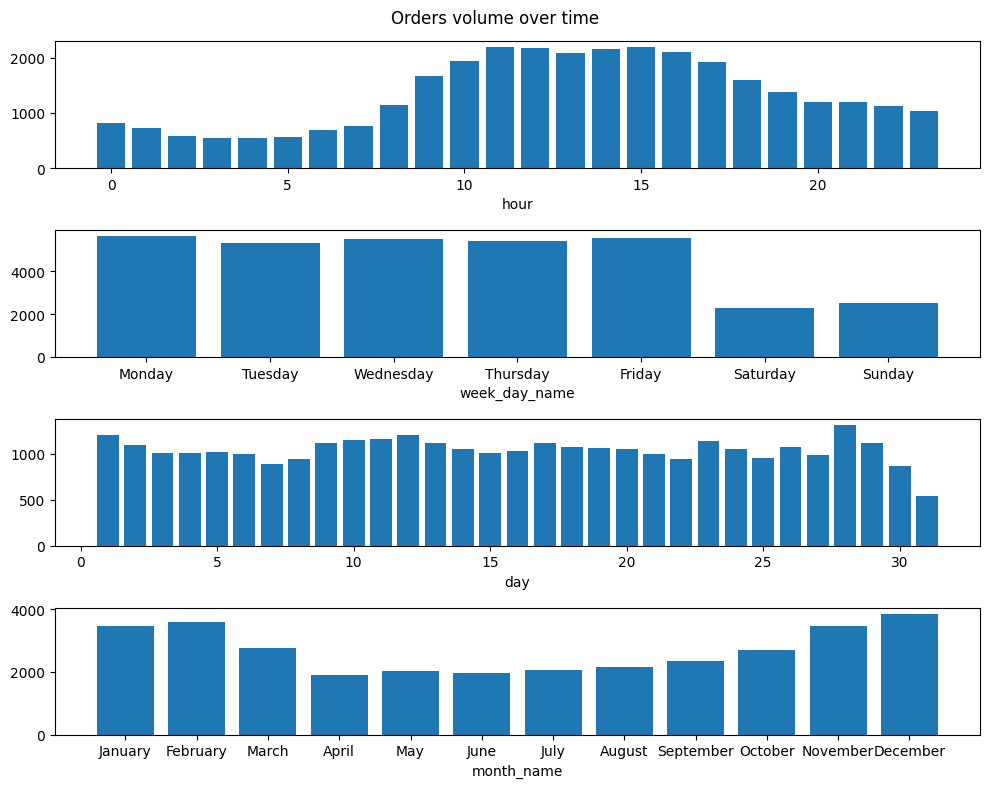

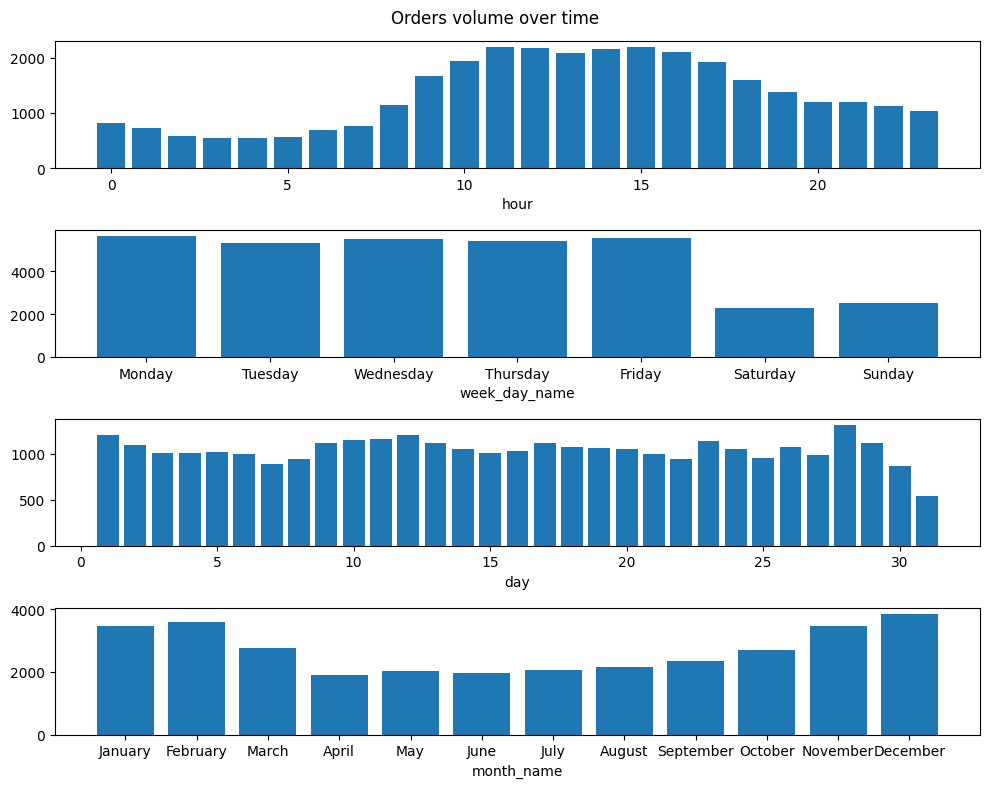

In [9]:
charts.data_over_time(orders_df,
                      ['hour','week_day_name','day','month_name'],
                      "Orders volume over time")

Peak Sale time:

    - During a day: 11:00 - 15:00
  
    - During a week: weekdays
  
    - During a month: flunctuate every week 
  
    - During a year: November to February
  
This provides insights on optimal time to run ads or promotions

# Order Item

In [10]:
order_item_df.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd,hour,week_day,week_day_name,day,month,month_name
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,10,0,Monday,19,3,March
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,19,0,Monday,19,3,March
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,6,1,Tuesday,20,3,March
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,9,1,Tuesday,20,3,March
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,11,1,Tuesday,20,3,March


In [11]:
order_item_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_item_id    40025 non-null  int64         
 1   created_at       40025 non-null  datetime64[us]
 2   order_id         40025 non-null  int64         
 3   product_id       40025 non-null  int64         
 4   is_primary_item  40025 non-null  int64         
 5   price_usd        40025 non-null  float64       
 6   cogs_usd         40025 non-null  float64       
 7   hour             40025 non-null  int64         
 8   week_day         40025 non-null  int64         
 9   week_day_name    40025 non-null  str           
 10  day              40025 non-null  int64         
 11  month            40025 non-null  int64         
 12  month_name       40025 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(8), str(2)
memory usage: 4.0 MB


## Examine sales

In [105]:
# Find the most ordered items
sales_per_pid = order_item_df.groupby(by="product_id").count()[["order_id"]]
sales_per_pid.columns = ["sales"]
sales_per_pid

,sales
product_id,
1,24226
2,5796
3,4985
4,5018


- The most popular item is The Original Mr. Fuzzy (PID:1)
- Its total sales is bigger than all of the other items' sales combined

=> Work out strategy to push the sales of other products too

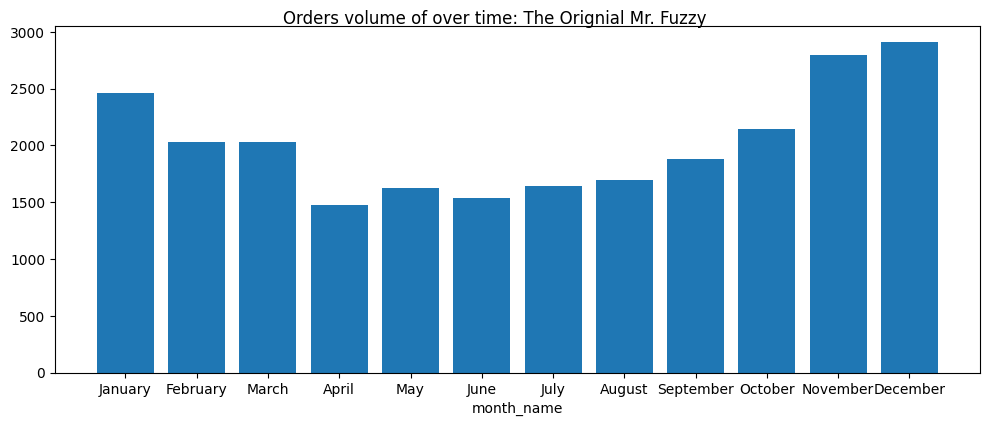

In [27]:
# Break down sale of each product over time

pid1_orders = order_item_df[order_item_df["product_id"]==1]
fig = charts.data_over_time(pid1_orders,['month_name'],"Orders volume of over time: The Orignial Mr. Fuzzy")
fig.set_size_inches(10,4)

- Sales is high during the end of year
- This product is a popular Christmas present
  

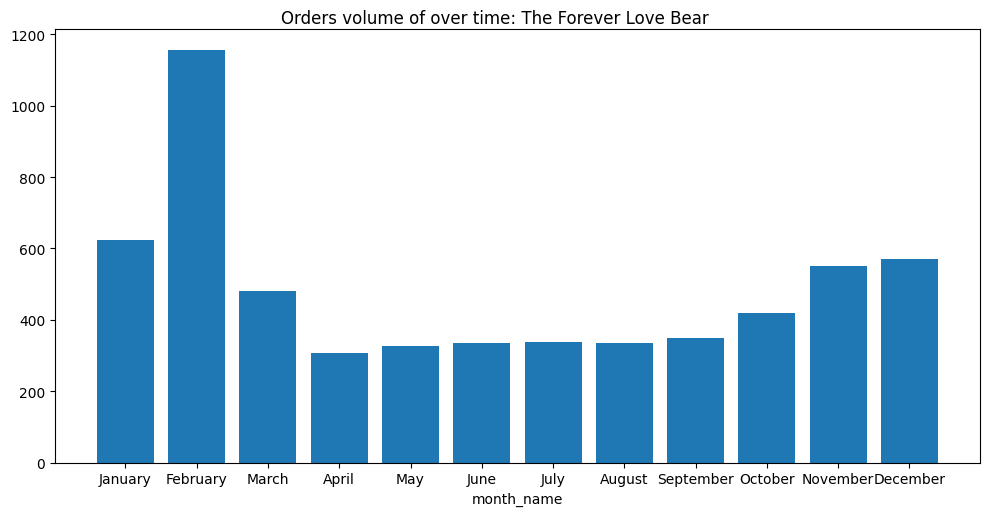

In [32]:
pid2_orders = order_item_df[order_item_df["product_id"]==2]
fig = charts.data_over_time(pid2_orders,['month_name'],"Orders volume of over time: The Forever Love Bear")
fig.set_size_inches(10,5)

- Sales peak during February
- As it is the Forever Love Bear, it is a popular present for Valentines
- However its Feb sale is still lower than The Orginial Mr. Fuzzy
- There should be plan to push the sale of this product during Valentines as it has potentials

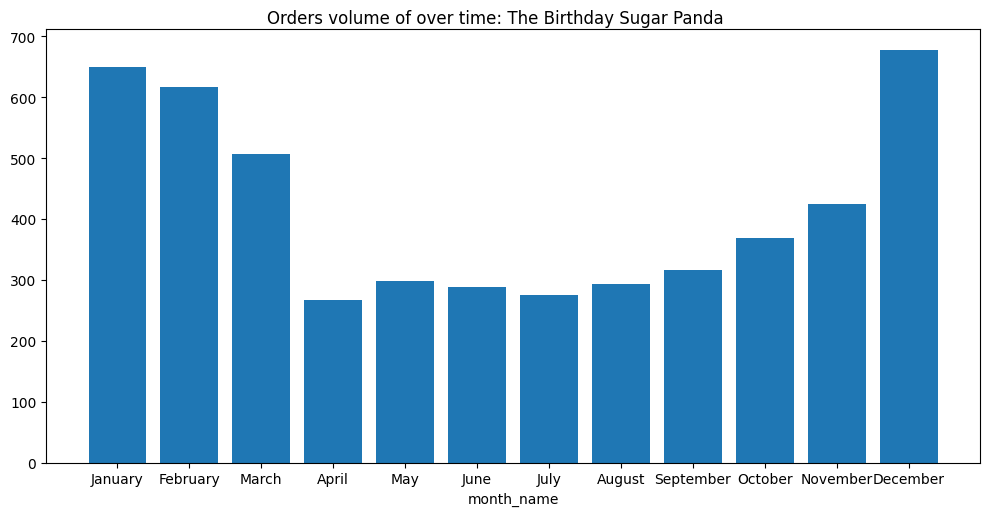

In [35]:
pid3_orders = order_item_df[order_item_df["product_id"]==3]
fig = charts.data_over_time(pid3_orders,['month_name'],"Orders volume of over time: The Birthday Sugar Panda")
fig.set_size_inches(10,5)

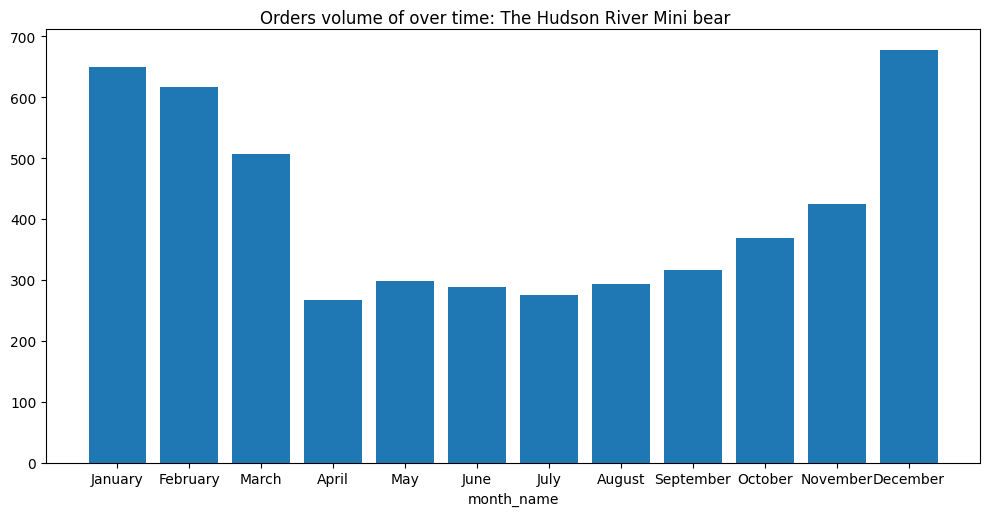

In [42]:

pid4_orders = order_item_df[order_item_df["product_id"]==4]
fig = charts.data_over_time(pid3_orders,['month_name'],"Orders volume of over time: The Hudson River Mini bear")
fig.set_size_inches(10,5)


- All products tend to increase in sales near the end of the year, indicating that our products are popular as Christmas presents

- However, while the Forever Love Bear (PID=2) sales does increase around the year-end period, it peaks in February. Given its name, it is a popular Valentine present.

- The company should come up with a strategy to drive during the mid year period (April - August) as this is the drought period

## Examine Profits

In [68]:
order_item_df["profit_usd"] = order_item_df["price_usd"] - order_item_df["cogs_usd"]
order_item_df.groupby(by="product_id").max()[["price_usd","cogs_usd","profit_usd"]]

,price_usd,cogs_usd,profit_usd
product_id,,,
1,49.99,19.49,30.5
2,59.99,22.49,37.5
3,45.99,14.49,31.5
4,29.99,9.49,20.5


- The Forever Love Bear (PID=2) has the highest margin while The Hudson River Mini bear (PID=4) has the lowest

In [72]:
order_item_df.groupby(by="product_id").sum(numeric_only=True)[["profit_usd"]]

,profit_usd
product_id,
1,738893.0
2,217350.0
3,157027.5
4,102869.0


- The Original Mr. Fuzzy does not have the highest margin but is the most profittable product of our company due to the massive volume of sales

# Order Item Refunds

In [50]:
refunds_df.head()

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd,hour,week_day,week_day_name,day,month,month_name
0,1,2012-04-06 11:32:43,57,57,49.99,11,4,Friday,6,4,April
1,2,2012-04-13 01:09:43,74,74,49.99,1,4,Friday,13,4,April
2,3,2012-04-15 07:03:48,71,71,49.99,7,6,Sunday,15,4,April
3,4,2012-04-17 20:00:37,118,118,49.99,20,1,Tuesday,17,4,April
4,5,2012-04-22 20:53:49,116,116,49.99,20,6,Sunday,22,4,April


In [51]:
refunds_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_item_refund_id  1731 non-null   int64         
 1   created_at            1731 non-null   datetime64[us]
 2   order_item_id         1731 non-null   int64         
 3   order_id              1731 non-null   int64         
 4   refund_amount_usd     1731 non-null   float64       
 5   hour                  1731 non-null   int64         
 6   week_day              1731 non-null   int64         
 7   week_day_name         1731 non-null   str           
 8   day                   1731 non-null   int64         
 9   month                 1731 non-null   int64         
 10  month_name            1731 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(7), str(2)
memory usage: 148.9 KB


In [ ]:
refunds_df
refunds_df.head()

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd,hour,week_day,week_day_name,day,month,month_name
0,1,2012-04-06 11:32:43,57,57,49.99,11,4,Friday,6,4,April
1,2,2012-04-13 01:09:43,74,74,49.99,1,4,Friday,13,4,April
2,3,2012-04-15 07:03:48,71,71,49.99,7,6,Sunday,15,4,April
3,4,2012-04-17 20:00:37,118,118,49.99,20,1,Tuesday,17,4,April
4,5,2012-04-22 20:53:49,116,116,49.99,20,6,Sunday,22,4,April


## Refunds over time

<Axes: xlabel='created_at'>

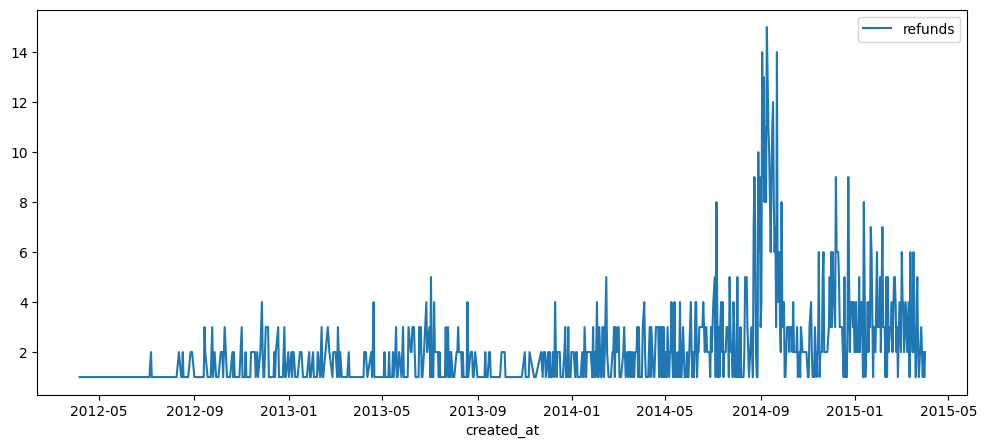

In [138]:
refund_by_date = refunds_df.groupby(by=refunds_df["created_at"].dt.date).count()[["order_item_refund_id"]]
refund_by_date.columns = ["refunds"]
refund_by_date.plot(figsize=(12,5))

- Refunds were very high during September 2014
  
- An investigation must be conducted on what was changed during this time that caused the spike in refunds (eg. change in manufactere, materials, etc).
- We need to gather more data about the causes of refunds to fully understand why customers are requesting refunds (eg. Change of mind, return due to quality, etc)

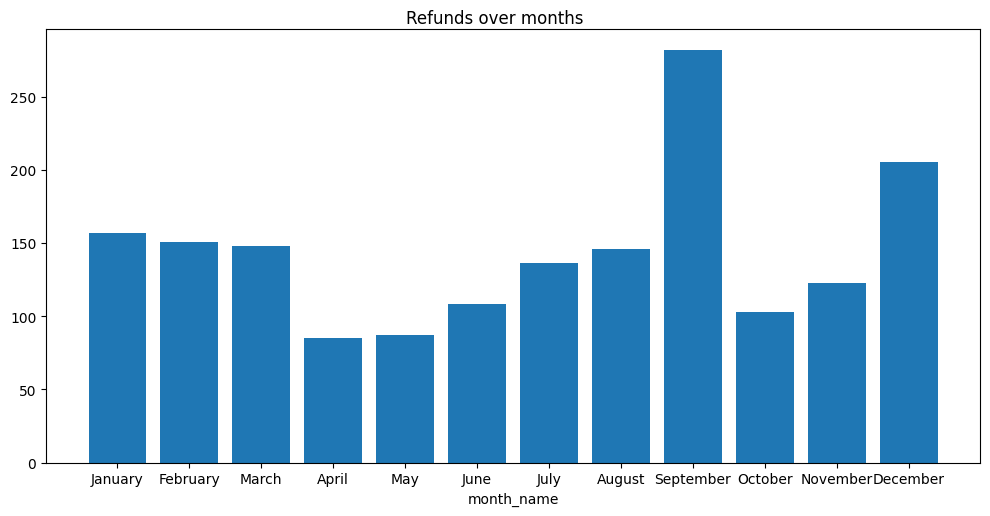

In [85]:
fig = charts.data_over_time(refunds_df,["month_name"],"Refunds over months")
fig.set_size_inches(10,5)

- Many of the refunds are issued in September. This needs to be investigated

## Refunds per product

In [88]:
order_item_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_item_id    40025 non-null  int64         
 1   created_at       40025 non-null  datetime64[us]
 2   order_id         40025 non-null  int64         
 3   product_id       40025 non-null  int64         
 4   is_primary_item  40025 non-null  int64         
 5   price_usd        40025 non-null  float64       
 6   cogs_usd         40025 non-null  float64       
 7   hour             40025 non-null  int64         
 8   week_day         40025 non-null  int64         
 9   week_day_name    0 non-null      category      
 10  day              40025 non-null  int64         
 11  month            40025 non-null  int64         
 12  month_name       40025 non-null  category      
 13  profit_usd       40025 non-null  float64       
dtypes: category(2), datetime64[us](1), float64(3), in

In [91]:
merge_ref_df = refunds_df.merge(order_item_df[["order_item_id","product_id"]],how="left",on="order_item_id")
merge_ref_df.head()

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd,hour,week_day,week_day_name,day,month,month_name,product_id
0,1,2012-04-06 11:32:43,57,57,49.99,11,4,NaN,6,4,April,1
1,2,2012-04-13 01:09:43,74,74,49.99,1,4,NaN,13,4,April,1
2,3,2012-04-15 07:03:48,71,71,49.99,7,6,NaN,15,4,April,1
3,4,2012-04-17 20:00:37,118,118,49.99,20,1,NaN,17,4,April,1
4,5,2012-04-22 20:53:49,116,116,49.99,20,6,NaN,22,4,April,1


In [ ]:
merge_ref_df.groupby(by="product_id").count(

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd,hour,week_day,week_day_name,day,month,month_name
product_id,,,,,,,,,,,
1,1237,1237,1237,1237,1237,1237,1237,0,1237,1237,1237
2,129,129,129,129,129,129,129,0,129,129,129
3,301,301,301,301,301,301,301,0,301,301,301
4,64,64,64,64,64,64,64,0,64,64,64


- While The Original Mr. Fuzzy Bear (PID = 1) generates the most sales and profits for the company, it also has the highest refund.
- But we must look at refund rate instead of refund number to fairly compare the products

In [107]:
refund_per_pid = merge_ref_df.groupby(by="product_id").count()[["order_id"]]
refund_per_pid.columns = ["refunds"]
refund_per_pid

,refunds
product_id,
1,1237
2,129
3,301
4,64


In [109]:
refund_rate = refund_per_pid.merge(sales_per_pid,on="product_id")
refund_rate["refund_rate (%)"] = (refund_rate["refunds"]/refund_rate["sales"])*100
refund_rate


,refunds,sales,refund_rate (%)
product_id,,,
1,1237,24226,5.106084
2,129,5796,2.225673
3,301,4985,6.038114
4,64,5018,1.275409


- Although The Original Mr. Fuzzy Bear (PID=1) has the highest number of refunds, its refund rate (5%) is only the second highest
- The Birthday Sugar Panda (PID=3) has the highest refund rate at 6%
- The causes for the high refund rates for both products must be investigated to improve customer experience and reduce occurrences of refunds

In [160]:
refund_by_item = merge_ref_df.groupby(by=[merge_ref_df["created_at"].dt.date,"product_id"]).count()[["order_item_refund_id"]]
refund_by_item.columns = ["refunds"]
refund_by_item 


refunds
created_at product_id         
2012-04-06 1                 1
2012-04-13 1                 1
2012-04-15 1                 1
2012-04-17 1                 1
2012-04-22 1                 1
...                        ...
2015-03-30 1                 1
           2                 1
2015-03-31 1                 1
2015-04-01 2                 1
           3                 1

[1056 rows x 1 columns]

<Axes: xlabel='created_at', ylabel='refunds'>

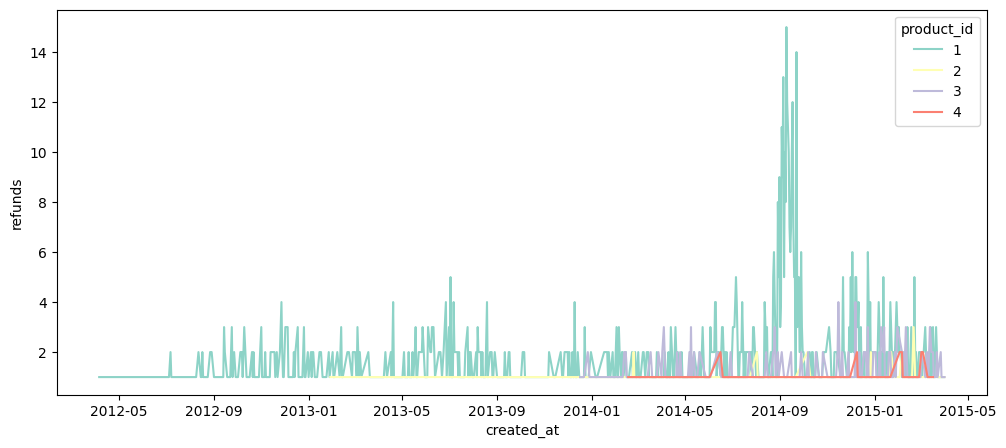

In [177]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=refund_by_item, x='created_at', y='refunds', hue='product_id',palette='Set3')

- The spike in refunds during September 2014 is all due to The Originial Mr. Fuzzy Bear.